In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from lightfm import LightFM
from lightfm.evaluation import precision_at_k as lfm_precision_at_k
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)

/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [ ]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

MIN_INTERACTIONS = 3

user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
before = len(df_filtered)
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(active_users) &
    df_filtered['ID_SKU'].isin(active_items)
]

print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")

Исходный датасет: (610913, 16)
Пользователей: 17,442
Товаров:       8,488
Взаимодействий:227,170


In [ ]:
# Уникальные взаимодействия с датой последней покупки
interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(last_date=('Дата', 'max'), count=('Дата', 'count'))
    .reset_index()
)

# Кодируем ID
users = interactions['Телефон_new'].unique()
items = interactions['ID_SKU'].unique()
user2id = {u: i for i, u in enumerate(users)}
item2id = {it: i for i, it in enumerate(items)}

interactions['user_id'] = interactions['Телефон_new'].map(user2id)
interactions['item_id'] = interactions['ID_SKU'].map(item2id)

n_users = len(users)
n_items = len(items)

interactions = interactions.sort_values('last_date')
split_ts = interactions['last_date'].quantile(0.7)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions['last_date'] <  split_ts]
test_df  = interactions[interactions['last_date'] >= split_ts]

# Только пользователи из трейна
train_users = set(train_df['user_id'].unique())
test_df = test_df[test_df['user_id'].isin(train_users)]

print(f"Train: {len(train_df):,} пар, {train_df['user_id'].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df['user_id'].nunique():,} users")

Дата разделения: 2017-04-18 23:48:00
Train: 162,552 пар, 15,609 users
Test:  24,193 пар,  3,824 users


In [4]:
def build_sparse(df, n_users, n_items):
    return csr_matrix(
        (np.ones(len(df)), (df['user_id'].values, df['item_id'].values)),
        shape=(n_users, n_items)
    )

train_matrix = build_sparse(train_df, n_users, n_items)
test_matrix  = build_sparse(test_df,  n_users, n_items)

print(f"Train matrix: {train_matrix.shape}, ненулевых: {train_matrix.nnz:,}")
print(f"Test matrix:  {test_matrix.shape},  ненулевых: {test_matrix.nnz:,}")

Train matrix: (17442, 8488), ненулевых: 162,552
Test matrix:  (17442, 8488),  ненулевых: 24,193


In [6]:
model = LightFM(
    no_components=64,
    loss='warp',
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=42
)

NUM_EPOCHS = 20
NUM_THREADS = 16

train_precisions = []
for epoch in range(NUM_EPOCHS):
    model.fit_partial(train_matrix, epochs=1, num_threads=NUM_THREADS)
    p = lfm_precision_at_k(model, train_matrix, k=10, num_threads=NUM_THREADS).mean()
    train_precisions.append(p)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: train Precision@10 = {p:.4f}")

print("Обучение завершено")

Epoch 1/20: train Precision@10 = 0.0661
Epoch 2/20: train Precision@10 = 0.0968
Epoch 3/20: train Precision@10 = 0.1245
Epoch 4/20: train Precision@10 = 0.1484
Epoch 5/20: train Precision@10 = 0.1726
Epoch 6/20: train Precision@10 = 0.1959
Epoch 7/20: train Precision@10 = 0.2200
Epoch 8/20: train Precision@10 = 0.2429
Epoch 9/20: train Precision@10 = 0.2670
Epoch 10/20: train Precision@10 = 0.2898
Epoch 11/20: train Precision@10 = 0.3124
Epoch 12/20: train Precision@10 = 0.3334
Epoch 13/20: train Precision@10 = 0.3521
Epoch 14/20: train Precision@10 = 0.3703
Epoch 15/20: train Precision@10 = 0.3862
Epoch 16/20: train Precision@10 = 0.4003
Epoch 17/20: train Precision@10 = 0.4126
Epoch 18/20: train Precision@10 = 0.4248
Epoch 19/20: train Precision@10 = 0.4357
Epoch 20/20: train Precision@10 = 0.4468
Обучение завершено


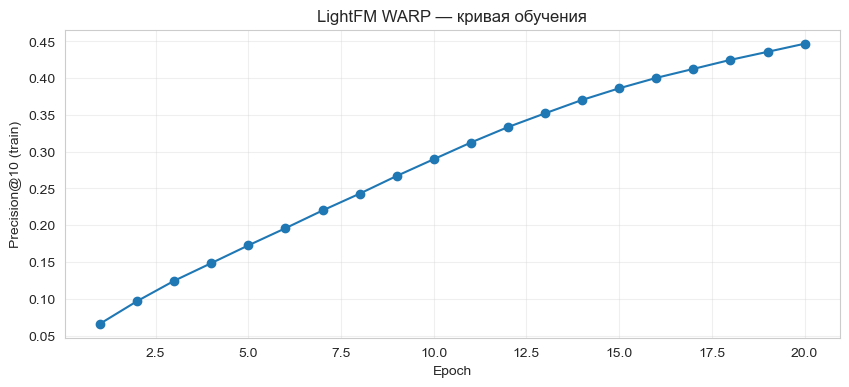

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_precisions, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Precision@10 (train)')
plt.title('LightFM WARP — кривая обучения')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if rec else 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0

def map_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(rec[:k]):
        if item in rel_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel_set), k)

def ndcg_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set: return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(rec[:k]) if item in rel_set)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel_set), k)))
    return dcg / idcg if idcg > 0 else 0.0


test_user_items = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
eval_users = list(test_user_items.keys())
print(f"Оценка на {len(eval_users):,} пользователях...")

K_VALUES = [5, 10, 20]
metrics = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in K_VALUES}
all_items = np.arange(n_items)

for user_id in eval_users:
    scores = model.predict(user_id, all_items)
    bought = set(train_matrix[user_id].indices)
    rec = [i for i in np.argsort(-scores) if i not in bought]
    rel = test_user_items[user_id]
    for k in K_VALUES:
        metrics[k]['precision'].append(precision_at_k(rec, rel, k))
        metrics[k]['recall'].append(recall_at_k(rec, rel, k))
        metrics[k]['map'].append(map_at_k(rec, rel, k))
        metrics[k]['ndcg'].append(ndcg_at_k(rec, rel, k))

results = {k: {m: float(np.mean(v)) for m, v in mv.items()} for k, mv in metrics.items()}
print("Готово")

Оценка на 3,824 пользователях...
Готово


In [9]:
print("=== LightFM WARP ===")
for k in K_VALUES:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")

=== LightFM WARP ===

K=5:
  Precision@5: 0.0510
  Recall@5:    0.0446
  MAP@5:       0.0407
  NDCG@5:      0.0627

K=10:
  Precision@10: 0.0438
  Recall@10:    0.0730
  MAP@10:       0.0386
  NDCG@10:      0.0691

K=20:
  Precision@20: 0.0352
  Recall@20:    0.1119
  MAP@20:       0.0404
  NDCG@20:      0.0813


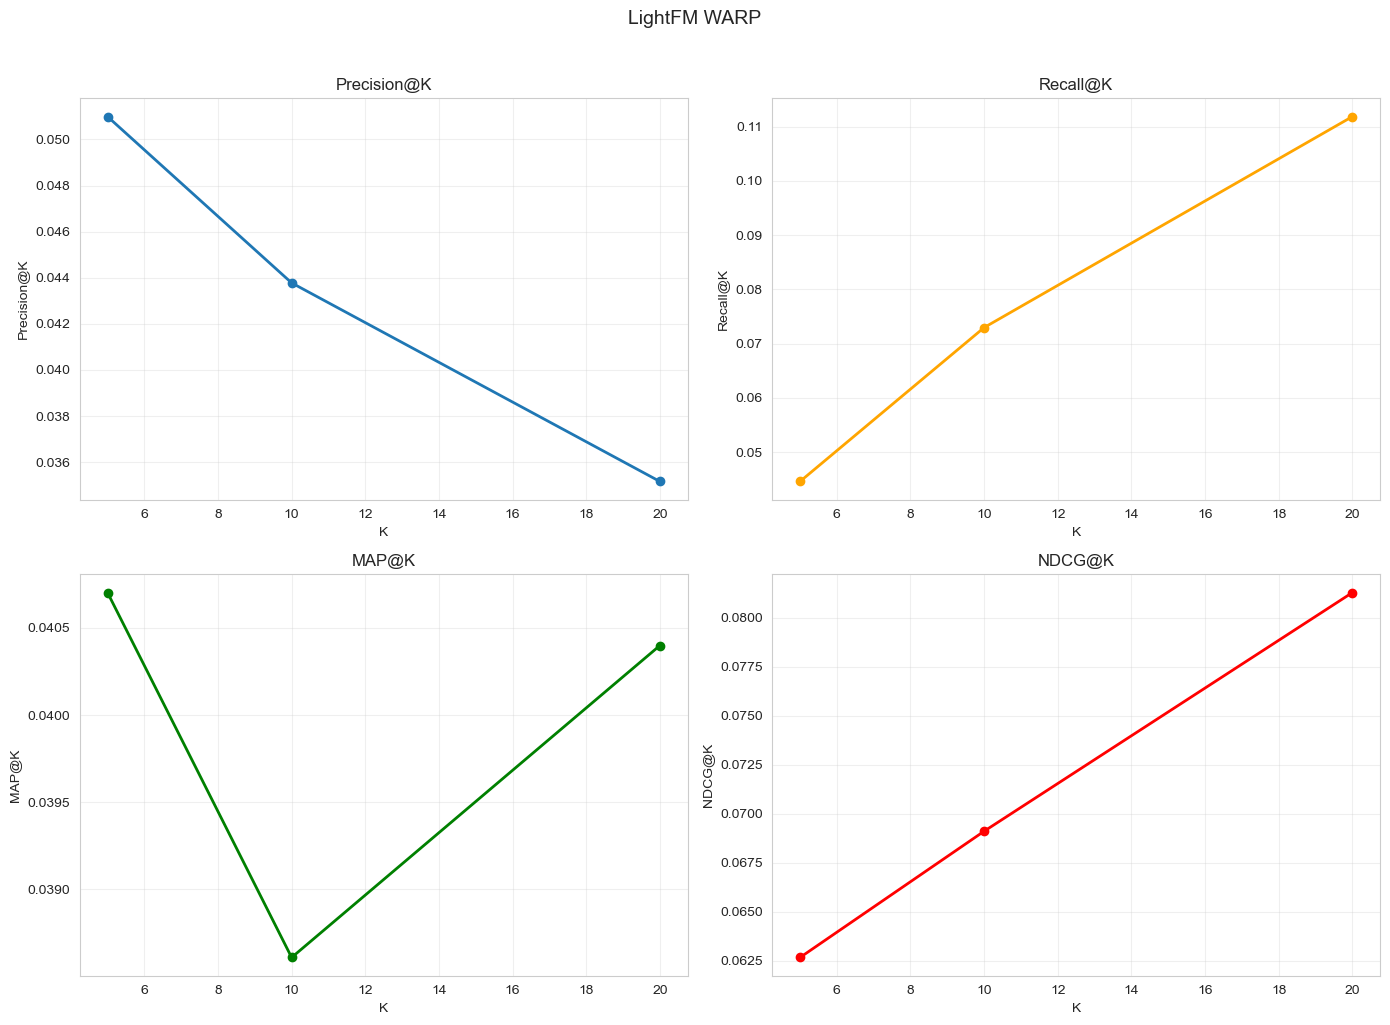

In [10]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('LightFM WARP', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()